#### Importing Required Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")

#### Plotting Defaults

In [2]:
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

COLORS = sns.color_palette("muted")
STATION_ORDER = ["S1_CNC_Machining", "S2_Welding", "S3_Assembly", "S4_Inspection", "S5_Packaging"]
STATION_LABELS = ["CNC Machining", "Welding", "Assembly", "Inspection", "Packaging"]

OUTPUT_DIR = "figures"
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{name}.png", bbox_inches="tight")
    plt.show()
    plt.close()

#### Load Raw Data

In [3]:
prod_raw = pd.read_csv("data/production_log.csv")
down_raw = pd.read_csv("data/downtime_events.csv")
qual_raw = pd.read_csv("data/quality_events.csv")
print("=== RAW DATA SHAPES ===")
print(f"  Production log : {prod_raw.shape[0]:>8,} rows × {prod_raw.shape[1]} cols")
print(f"  Downtime events: {down_raw.shape[0]:>8,} rows × {down_raw.shape[1]} cols")
print(f"  Quality events : {qual_raw.shape[0]:>8,} rows × {qual_raw.shape[1]} cols")


=== RAW DATA SHAPES ===
  Production log :  180,481 rows × 13 cols
  Downtime events:      109 rows × 7 cols
  Quality events :    3,873 rows × 7 cols


#### Missing Values

In [4]:
print("\n=== MISSING VALUES (Production Log) ===")
missing = prod_raw.isnull().sum()
missing_pct = (prod_raw.isnull().mean() * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "pct": missing_pct})
print(missing_report[missing_report["missing_count"] > 0].to_string())


=== MISSING VALUES (Production Log) ===
                   missing_count    pct
shift                       3601   2.00
operator                   75111  41.62
queue_wait_min              3749   2.08
downtime_wait_min           3486   1.93
cycle_time_min              3614   2.00
blocking_time_min           3614   2.00
start_min                   3576   1.98
end_min                     3533   1.96


#### Duplicate Values (rows identical on (part_id, station, status))

In [5]:
dup_key = ["part_id", "station", "status"]
n_dupes_prod = prod_raw.duplicated(subset=dup_key, keep="first").sum()
n_dupes_down = down_raw.duplicated(keep="first").sum()
n_dupes_qual = qual_raw.duplicated(subset=["part_id", "station", "defect_type"], keep="first").sum()
print("\n=== DUPLICATE RECORDS ===")
print(f"  Production log : {n_dupes_prod} duplicates "
      f"({n_dupes_prod / len(prod_raw) * 100:.2f}%)")
print(f"  Downtime events: {n_dupes_down} duplicates")
print(f"  Quality events : {n_dupes_qual} duplicates")


=== DUPLICATE RECORDS ===
  Production log : 897 duplicates (0.50%)
  Downtime events: 0 duplicates
  Quality events : 19 duplicates


### **Cleaning decisions:**
##### - Drop duplicate rows (keep first occurrence).
##### - For missing numeric values (cycle times, queue waits), impute with station-level medians. Median is preferred over mean to avoid influence from outlier breakdown-related waits.
##### - Missing `shift` values are inferred from the `start_timestamp`.
##### - Missing `operator` values on automated stations are expected (no operator assigned); on manual stations they're flagged as unknown.

In [6]:
# clean production log
prod = prod_raw.drop_duplicates(subset=dup_key, keep="first").copy()

# parse timestamps
prod["start_dt"] = pd.to_datetime(prod["start_timestamp"], errors="coerce")
prod["end_dt"] = pd.to_datetime(prod["end_timestamp"], errors="coerce")
prod["date"] = prod["start_dt"].dt.date

# input missing shift from timestamp
def infer_shift(hour):
    if pd.isna(hour):
        return np.nan
    if 6 <= hour < 14:
        return 1
    elif 14 <= hour < 22:
        return 2
    else:
        return 3

missing_shift = prod["shift"].isna()
prod.loc[missing_shift, "shift"] = (prod.loc[missing_shift, "start_dt"].dt.hour.apply(infer_shift))
prod["shift"] = prod["shift"].astype("Int64")

# input missing numerics with station-level medians
numeric_cols = ["cycle_time_min", "queue_wait_min", "downtime_wait_min"]
for col in numeric_cols:
    station_medians = prod.groupby("station")[col].transform("median")
    prod[col] = prod[col].fillna(station_medians)

# fill remaining edge-case NaNs with global median
for col in numeric_cols:
    prod[col] = prod[col].fillna(prod[col].median())

# flag unknown operators on manual stations
manual_stations = ["S3_Assembly", "S4_Inspection", "S5_Packaging"]
prod.loc[prod["station"].isin(manual_stations) & prod["operator"].isna(), "operator"] = "UNKNOWN"

# cleaning downtime log
down = down_raw.drop_duplicates(keep="first").copy()
down["start_dt"] = pd.to_datetime(down["start_timestamp"], errors="coerce")
down["end_dt"] = pd.to_datetime(down["end_timestamp"], errors="coerce")

# input missing duration if possible
mask = down["duration_min"].isna() & down["start_dt"].notna() & down["end_dt"].notna()
down.loc[mask, "duration_min"] = ((down.loc[mask, "end_dt"] - down.loc[mask, "start_dt"]).dt.total_seconds() / 60)

# cleaning quality log
qual = qual_raw.drop_duplicates(subset=["part_id", "station", "defect_type"], keep="first").copy()
qual["detection_dt"] = pd.to_datetime(qual["detection_time_timestamp"],errors="coerce")

print(f"\n=== CLEAN DATA SHAPES ===")
print(f"  Production log : {len(prod):>8,} rows  "
      f"(removed {len(prod_raw) - len(prod):,} dupes)")
print(f"  Downtime events: {len(down):>8,} rows  "
      f"(removed {len(down_raw) - len(down):,} dupes)")
print(f"  Quality events : {len(qual):>8,} rows  "
      f"(removed {len(qual_raw) - len(qual):,} dupes)")
print(f"  Remaining NaNs in production log: "
      f"{prod[numeric_cols].isna().sum().sum()}")


=== CLEAN DATA SHAPES ===
  Production log :  179,584 rows  (removed 897 dupes)
  Downtime events:      109 rows  (removed 0 dupes)
  Quality events :    3,854 rows  (removed 19 dupes)
  Remaining NaNs in production log: 0


## Production Overview

### Key top-line metrics

In [7]:
# key metrics
parts_entered = prod["part_id"].nunique()
parts_at_last = prod[prod["station"] == "S5_Packaging"]
parts_completed = parts_at_last[parts_at_last["status"] == "good"]["part_id"].nunique()
parts_scrapped = prod[prod["status"] == "scrapped"]["part_id"].nunique()

# parts still in system at sim end
parts_wip = parts_entered - (parts_completed + parts_scrapped)

print("=== Production Overview (Q1 2024, 90 Days) ===")
print(f"  Parts entered line         : {parts_entered}")
print(f"  Parts completed            : {parts_completed}")
print(f"  Parts scrapped             : {parts_scrapped}")
print(f"  Parts in WIP at end of run : {parts_wip}")
print(f"  Throughput yield           : {parts_completed / parts_entered * 100:.1f}%")
print(f"  First-pass yield           : {parts_completed / (parts_completed + parts_scrapped) * 100:.1f}%")
print(f"  Average daily throughput   : {parts_completed / 90:.0f} parts/day")




=== Production Overview (Q1 2024, 90 Days) ===
  Parts entered line         : 37960
  Parts completed            : 34031
  Parts scrapped             : 3854
  Parts in WIP at end of run : 75
  Throughput yield           : 89.6%
  First-pass yield           : 89.8%
  Average daily throughput   : 378 parts/day


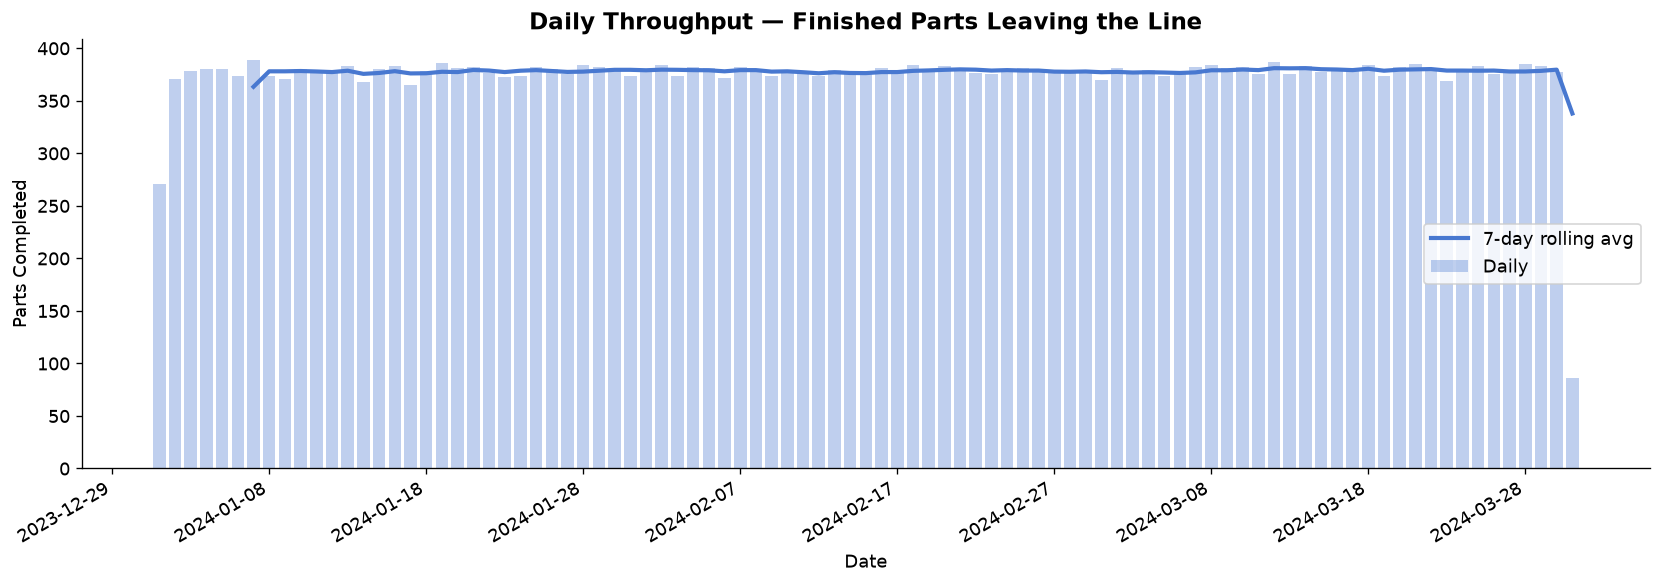

In [8]:
# Daily throughput trend
daily_completed = (prod[(prod["station"] == "S5_Packaging") & (prod["status"] == "good")].groupby("date")["part_id"].nunique().reset_index(name="completed"))
daily_completed["date"] = pd.to_datetime(daily_completed["date"])
daily_completed["rolling_7d"] = daily_completed["completed"].rolling(7).mean()

fig, ax = plt.subplots(figsize=(14,5))
ax.bar(daily_completed["date"], daily_completed["completed"], alpha=0.35, color=COLORS[0], label="Daily")
ax.plot(daily_completed["date"], daily_completed["rolling_7d"], color=COLORS[0], linewidth=2.5, label="7-day rolling avg")
ax.set_xlabel("Date")
ax.set_ylabel("Parts Completed")
ax.set_title("Daily Throughput — Finished Parts Leaving the Line")
ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(12))
fig.autofmt_xdate(rotation=30)
savefig("01_daily_throughput")


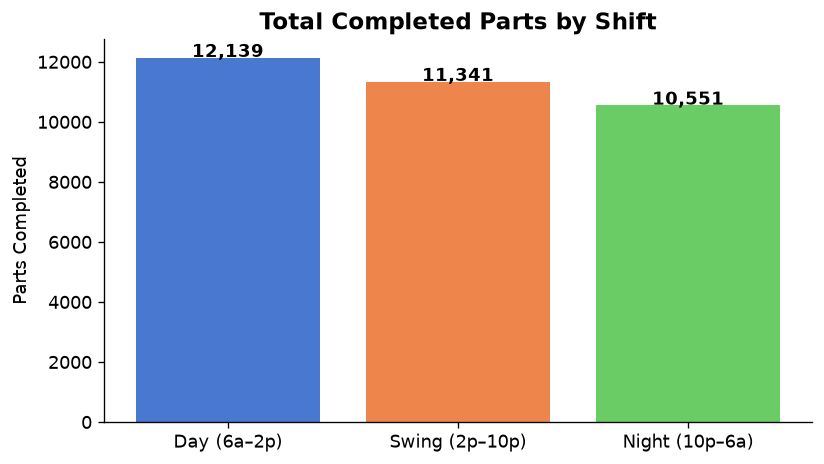

In [9]:
# Throughput by shift
shift_throughput = (prod[(prod["station"] == "S5_Packaging") & (prod["status"] == "good")].groupby("shift")["part_id"].nunique().reindex([1, 2, 3]))
shift_labels = ["Day (6a–2p)", "Swing (2p–10p)", "Night (10p–6a)"]
 
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(shift_labels, shift_throughput.values, color=COLORS[:3])
for bar, val in zip(bars, shift_throughput.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,f"{val:,}", ha="center", fontweight="bold")
ax.set_ylabel("Parts Completed")
ax.set_title("Total Completed Parts by Shift")
savefig("02_shift_throughput")

### OEE Analysis

=== OEE BREAKDOWN BY STATION ===

  CNC Machining     A=99.4%  P=66.3%  Q=96.9%  → OEE=63.9%
  Welding           A=99.2%  P=85.8%  Q=98.0%  → OEE=83.4%
  Assembly          A=100.0%  P=55.6%  Q=95.6%  → OEE=53.1%
  Inspection        A=99.8%  P=93.2%  Q=100.0%  → OEE=92.9%
  Packaging         A=99.8%  P=53.2%  Q=98.9%  → OEE=52.5%


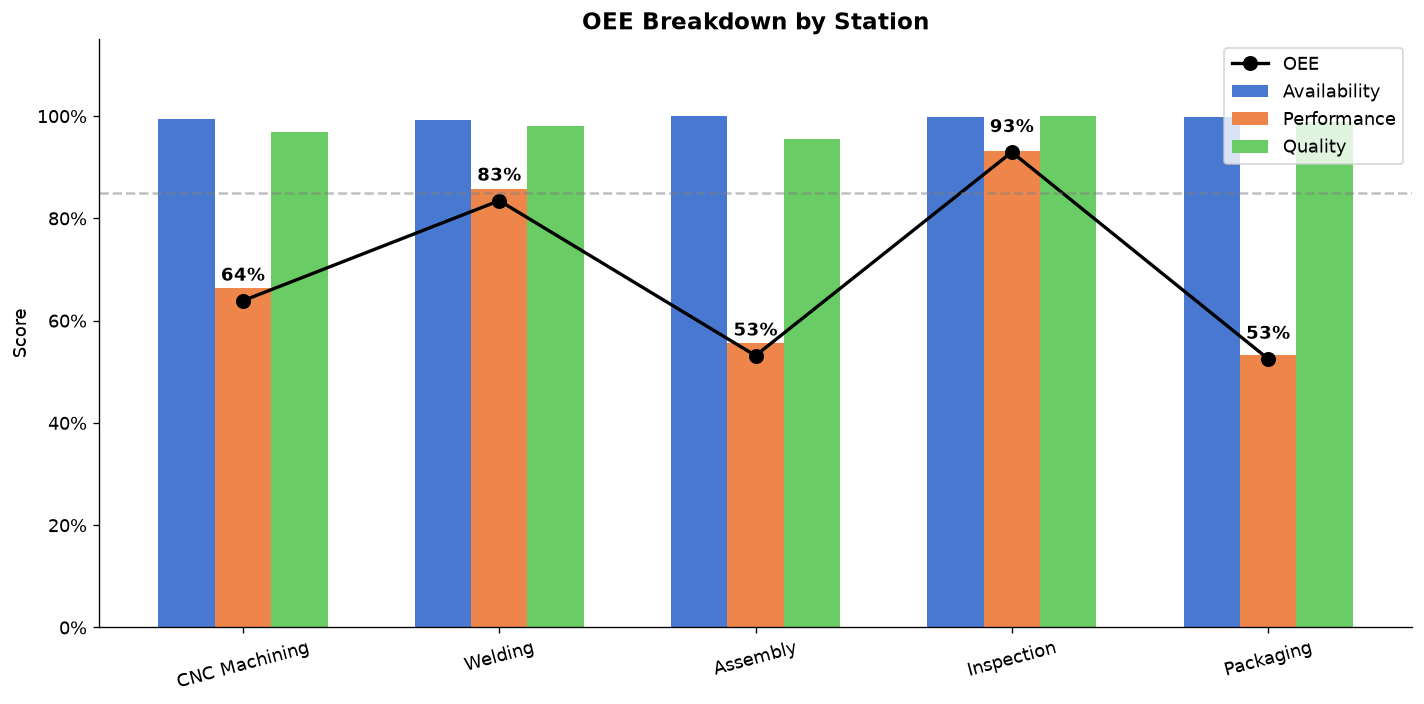

In [10]:
SIM_DAYS = 90
TOTAL_SCHEDULED_MIN = SIM_DAYS * 24 * 60  # 3 shifts, no planned downtime

oee_data = []

for station_name, label in zip(STATION_ORDER, STATION_LABELS):
    st_prod = prod[prod["station"] == station_name]
    st_down = down[down["station"] == station_name]

    # Get station config for ideal cycle time
    ideal_ct = {"S1_CNC_Machining": 4.5, "S2_Welding": 3.0, "S3_Assembly": 6.0, "S4_Inspection": 3.5, "S5_Packaging": 2.0}
    num_machines = {"S1_CNC_Machining": 2, "S2_Welding": 1, "S3_Assembly": 3, "S4_Inspection": 1, "S5_Packaging": 1}

    # AVAILABILITY = (Scheduled - Downtime) / Scheduled
    total_downtime = st_down["duration_min"].sum() if len(st_down) > 0 else 0
    scheduled = TOTAL_SCHEDULED_MIN * num_machines[station_name]
    availability = (scheduled - total_downtime) / scheduled

    # PERFORMANCE = (Ideal Cycle Time × Parts Processed) / Operating Time
    parts_processed = len(st_prod)
    operating_time = scheduled - total_downtime
    performance = (ideal_ct[station_name] * parts_processed) / operating_time
    performance = min(performance, 1.0)  # Cap at 100%

    # QUALITY = Good Parts / Total Parts
    good_parts = len(st_prod[st_prod["status"] == "good"])
    quality = good_parts / parts_processed if parts_processed > 0 else 0

    oee = availability * performance * quality
    oee_data.append({"station" : label, "availability" : availability, "performance" : performance, "quality" : quality, "oee" : oee, "downtime_hrs" : total_downtime / 60, "parts_processed" : parts_processed})

oee_df = pd.DataFrame(oee_data)

# Print OEE table
print("=== OEE BREAKDOWN BY STATION ===\n")
for _, row in oee_df.iterrows():
    print(f"  {row['station']:<16s}  "
          f"A={row['availability']:.1%}  "
          f"P={row['performance']:.1%}  "
          f"Q={row['quality']:.1%}  "
          f"→ OEE={row['oee']:.1%}")

# OEE waterfall chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(oee_df))
width = 0.22
 
ax.bar(x - width, oee_df["availability"], width, label="Availability",
       color=COLORS[0])
ax.bar(x, oee_df["performance"], width, label="Performance",
       color=COLORS[1])
ax.bar(x + width, oee_df["quality"], width, label="Quality",
       color=COLORS[2])
 
# OEE line overlay
ax.plot(x, oee_df["oee"], "ko-", markersize=8, linewidth=2, label="OEE")
for i, val in enumerate(oee_df["oee"]):
    ax.annotate(f"{val:.0%}", (i, val), textcoords="offset points",
                xytext=(0, 12), ha="center", fontweight="bold")
 
ax.set_xticks(x)
ax.set_xticklabels(oee_df["station"], rotation=15)
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylabel("Score")
ax.set_title("OEE Breakdown by Station")
ax.legend(loc="upper right")
ax.axhline(y=0.85, color="gray", linestyle="--", alpha=0.5, label="World-class (85%)")
savefig("03_oee_by_station")

## Bottleneck Identification

### Queue wait time by station

=== QUEUE WAIT TIME BY STATION (minutes) ===

               mean  median   std    p95
CNC Machining  67.2    70.4  46.0  135.3
Welding        91.9    98.9  26.9  116.6
Assembly       74.6    77.0  14.4   89.0
Inspection     71.1    71.1   6.7   79.8
Packaging       0.1     0.0   0.9    0.5


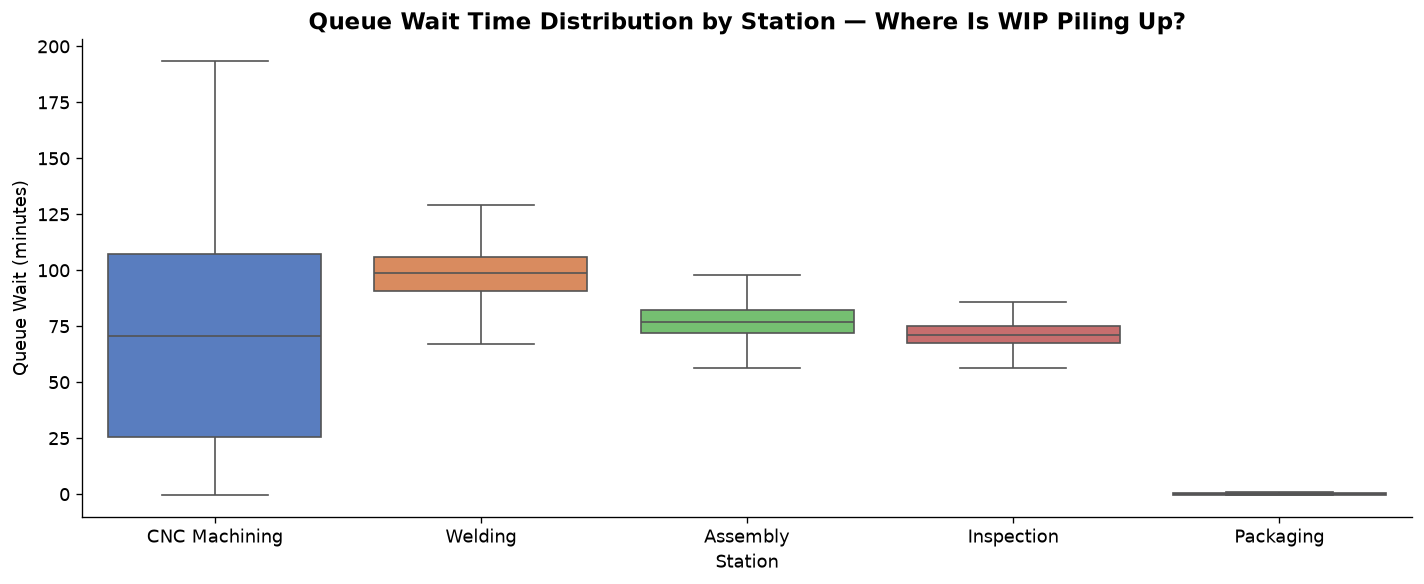

In [11]:
queue_stats = (
    prod.groupby("station")["queue_wait_min"]
    .agg(["mean", "median", "std", lambda x: x.quantile(0.95)])
    .rename(columns={"<lambda_0>": "p95"})
    .reindex(STATION_ORDER)
)
queue_stats.index = STATION_LABELS

print("=== QUEUE WAIT TIME BY STATION (minutes) ===\n")
print(queue_stats.round(1).to_string())

# Queue wait distribution (box plot)
plot_data = prod.copy()
plot_data["station_label"] = plot_data["station"].map(
    dict(zip(STATION_ORDER, STATION_LABELS))
)
 
fig, ax = plt.subplots(figsize=(12, 5))
station_order_labels = [dict(zip(STATION_ORDER, STATION_LABELS))[s]
                        for s in STATION_ORDER]
sns.boxplot(data=plot_data, x="station_label", y="queue_wait_min",
            order=station_order_labels, palette="muted",
            showfliers=False, ax=ax)
ax.set_xlabel("Station")
ax.set_ylabel("Queue Wait (minutes)")
ax.set_title("Queue Wait Time Distribution by Station — "
             "Where Is WIP Piling Up?")
savefig("04_queue_wait_boxplot")

### Utilization rate

In [12]:
# Utilization rate: what fraction of time each station's machines were busy
print("\n=== STATION UTILIZATION ===\n")
for station_name, label in zip(STATION_ORDER, STATION_LABELS):
    st_prod = prod[prod["station"] == station_name]
    total_processing_min = st_prod["cycle_time_min"].sum()
    n_machines = {"S1_CNC_Machining": 2, "S2_Welding": 1,
                  "S3_Assembly": 3, "S4_Inspection": 1,
                  "S5_Packaging": 1}[station_name]
    capacity_min = TOTAL_SCHEDULED_MIN * n_machines
    utilization = total_processing_min / capacity_min
    print(f"  {label:<16s}  {utilization:.1%} utilization  "
          f"({n_machines} machine{'s' if n_machines > 1 else ''})")


=== STATION UTILIZATION ===

  CNC Machining     65.9% utilization  (2 machines)
  Welding           85.2% utilization  (1 machine)
  Assembly          59.7% utilization  (3 machines)
  Inspection        99.7% utilization  (1 machine)
  Packaging         57.1% utilization  (1 machine)


## Downtime Analysis

### Downtime Pareto by Cause

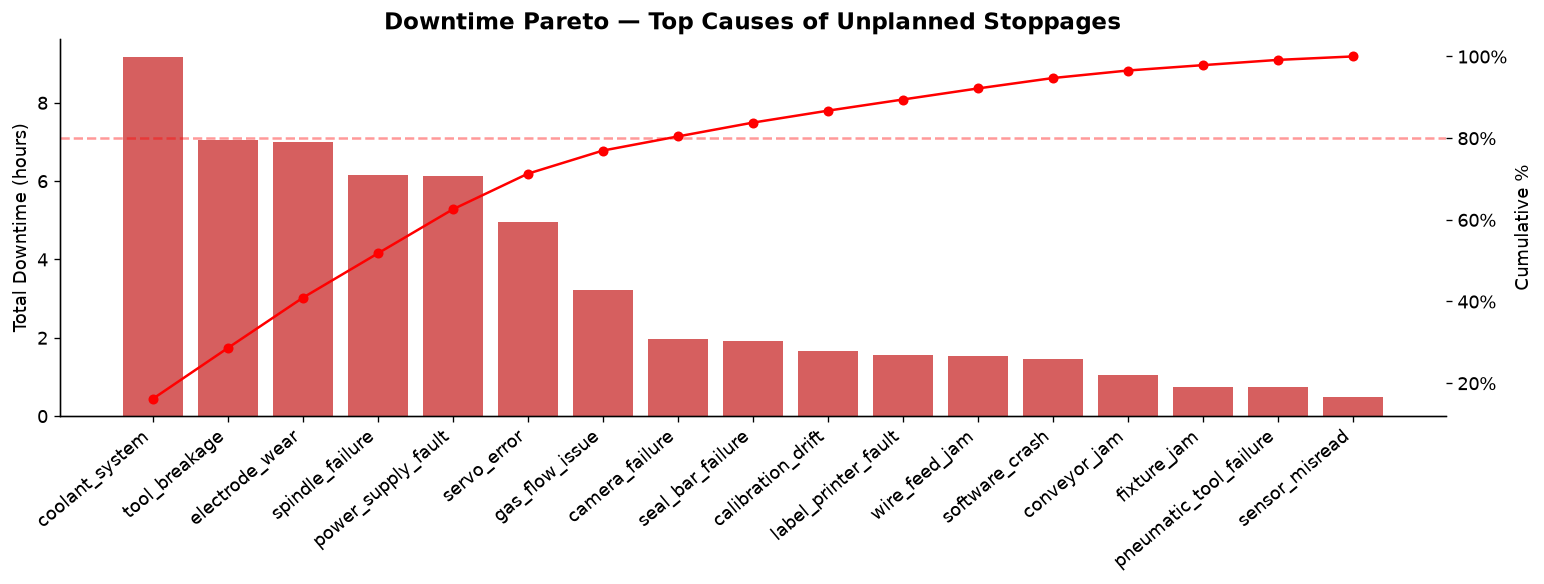

In [13]:
cause_totals = (
    down.groupby("cause")["duration_min"]
    .sum()
    .sort_values(ascending=False)
)
cause_totals_hrs = cause_totals / 60
cumulative_pct = cause_totals.cumsum() / cause_totals.sum()
 
fig, ax1 = plt.subplots(figsize=(13, 5))
bars = ax1.bar(range(len(cause_totals_hrs)), cause_totals_hrs.values,
               color=COLORS[3])
ax1.set_xticks(range(len(cause_totals_hrs)))
ax1.set_xticklabels(cause_totals_hrs.index, rotation=40, ha="right")
ax1.set_ylabel("Total Downtime (hours)")
ax1.set_title("Downtime Pareto — Top Causes of Unplanned Stoppages")
 
ax2 = ax1.twinx()
ax2.plot(range(len(cumulative_pct)), cumulative_pct.values, "ro-", markersize=5)
ax2.set_ylabel("Cumulative %")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.axhline(y=0.8, color="red", linestyle="--", alpha=0.4)
savefig("05_downtime_pareto")

### Downtime by Station

In [14]:
station_downtime = (
    down.groupby("station")["duration_min"]
    .agg(["sum", "count", "mean"])
    .rename(columns={"sum": "total_min", "count": "events", "mean": "avg_min"})
    .reindex(STATION_ORDER)
)
station_downtime.index = STATION_LABELS
station_downtime["total_hrs"] = station_downtime["total_min"] / 60
 
print("=== DOWNTIME BY STATION ===\n")
print(station_downtime[["events", "total_hrs", "avg_min"]].round(1).to_string())

=== DOWNTIME BY STATION ===

               events  total_hrs  avg_min
CNC Machining      37       27.3     44.3
Welding            34       17.9     31.5
Assembly            8        2.0     14.7
Inspection         16        5.1     19.0
Packaging          14        4.5     19.4


### MTBF / MTTR by station

In [15]:
print("\n=== MTBF & MTTR BY STATION ===\n")
for station_name, label in zip(STATION_ORDER, STATION_LABELS):
    st_down = down[down["station"] == station_name]
    n_failures = len(st_down)
    if n_failures > 0:
        total_down_min = st_down["duration_min"].sum()
        operating_hrs = (TOTAL_SCHEDULED_MIN - total_down_min) / 60
        mtbf = operating_hrs / n_failures
        mttr = total_down_min / n_failures
        print(f"  {label:<16s}  MTBF = {mtbf:.1f} hrs  |  "
              f"MTTR = {mttr:.1f} min  |  {n_failures} events")


=== MTBF & MTTR BY STATION ===

  CNC Machining     MTBF = 57.6 hrs  |  MTTR = 44.3 min  |  37 events
  Welding           MTBF = 63.0 hrs  |  MTTR = 31.5 min  |  34 events
  Assembly          MTBF = 269.8 hrs  |  MTTR = 14.7 min  |  8 events
  Inspection        MTBF = 134.7 hrs  |  MTTR = 19.0 min  |  16 events
  Packaging         MTBF = 154.0 hrs  |  MTTR = 19.4 min  |  14 events


## Quality and Defect Analysis

### Defect Pareto

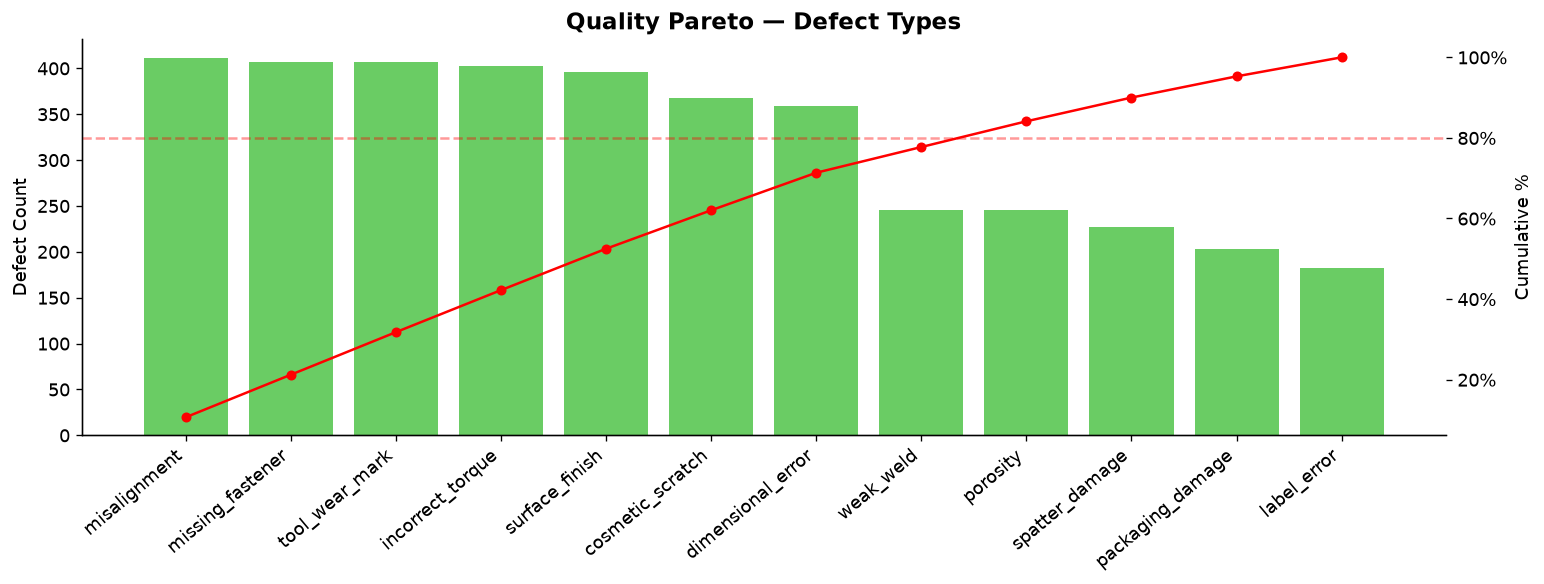

In [16]:
defect_counts = qual["defect_type"].value_counts()
defect_cum_pct = defect_counts.cumsum() / defect_counts.sum()
 
fig, ax1 = plt.subplots(figsize=(13, 5))
bars = ax1.bar(range(len(defect_counts)), defect_counts.values, color=COLORS[2])
ax1.set_xticks(range(len(defect_counts)))
ax1.set_xticklabels(defect_counts.index, rotation=40, ha="right")
ax1.set_ylabel("Defect Count")
ax1.set_title("Quality Pareto — Defect Types")
 
ax2 = ax1.twinx()
ax2.plot(range(len(defect_cum_pct)), defect_cum_pct.values, "ro-", markersize=5)
ax2.set_ylabel("Cumulative %")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.axhline(y=0.8, color="red", linestyle="--", alpha=0.4)
savefig("06_defect_pareto")

### Scrap Rate by Station

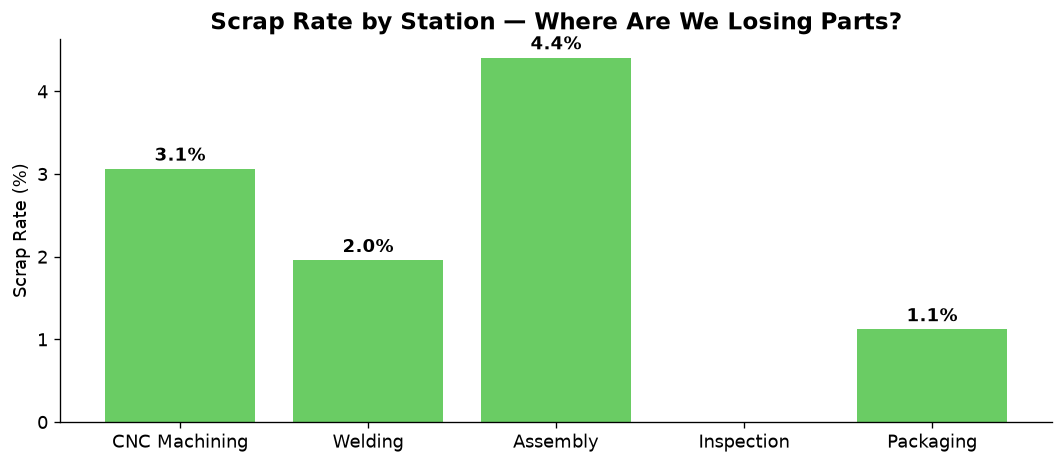

In [17]:
station_quality = (
    prod.groupby("station")
    .apply(lambda g: pd.Series({
        "total": len(g),
        "scrapped": (g["status"] == "scrapped").sum(),
    }))
    .reindex(STATION_ORDER)
)
station_quality["scrap_rate"] = station_quality["scrapped"] / station_quality["total"]
station_quality.index = STATION_LABELS
 
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(station_quality.index, station_quality["scrap_rate"] * 100,
              color=COLORS[2])
for bar, val in zip(bars, station_quality["scrap_rate"]):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                f"{val:.1%}", ha="center", fontweight="bold")
ax.set_ylabel("Scrap Rate (%)")
ax.set_title("Scrap Rate by Station — Where Are We Losing Parts?")
savefig("07_scrap_by_station")

## Shift and Operator Performance

### Cycle Time by Shift for Manual Stations

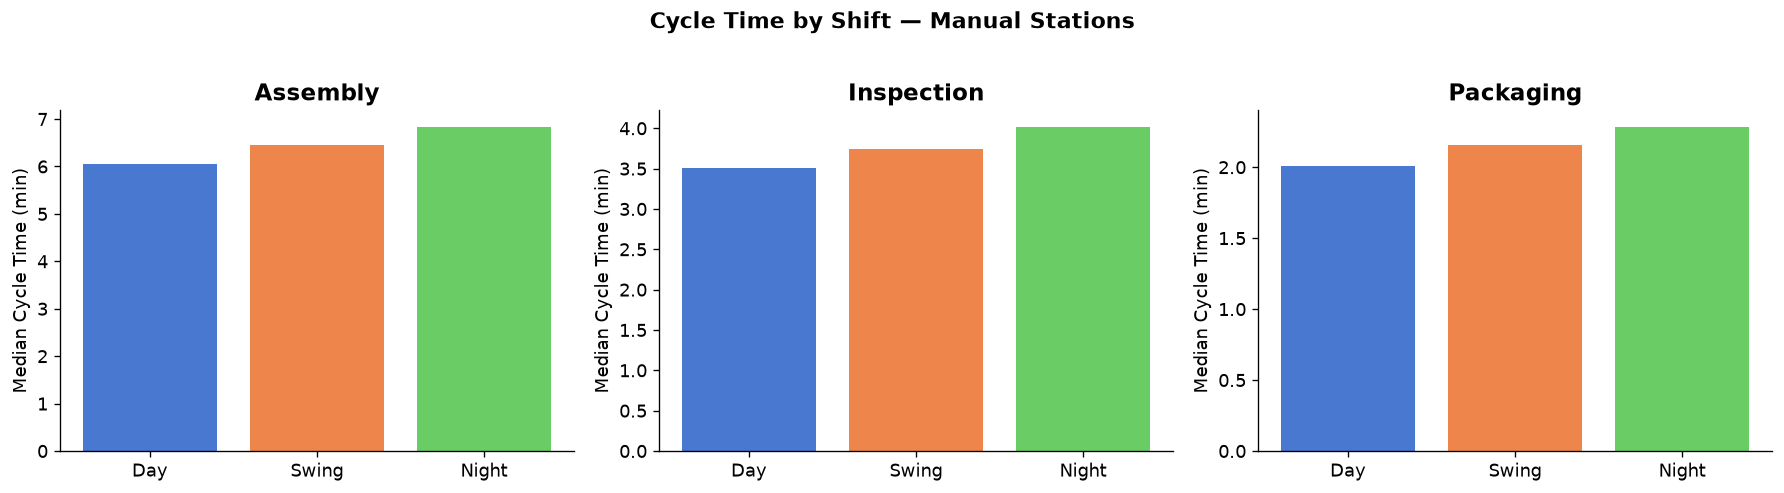

In [18]:
manual_prod = prod[prod["station"].isin(manual_stations)]
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, station_name, label in zip(axes, manual_stations,
                                     ["Assembly", "Inspection", "Packaging"]):
    st = manual_prod[manual_prod["station"] == station_name]
    shift_ct = st.groupby("shift")["cycle_time_min"].median()
    ax.bar(["Day", "Swing", "Night"], shift_ct.reindex([1, 2, 3]).values,
           color=COLORS[:3])
    ax.set_title(label)
    ax.set_ylabel("Median Cycle Time (min)")
 
plt.suptitle("Cycle Time by Shift — Manual Stations", fontweight="bold", y=1.02)
savefig("08_cycle_time_by_shift")

### Scrap Rate by Shift

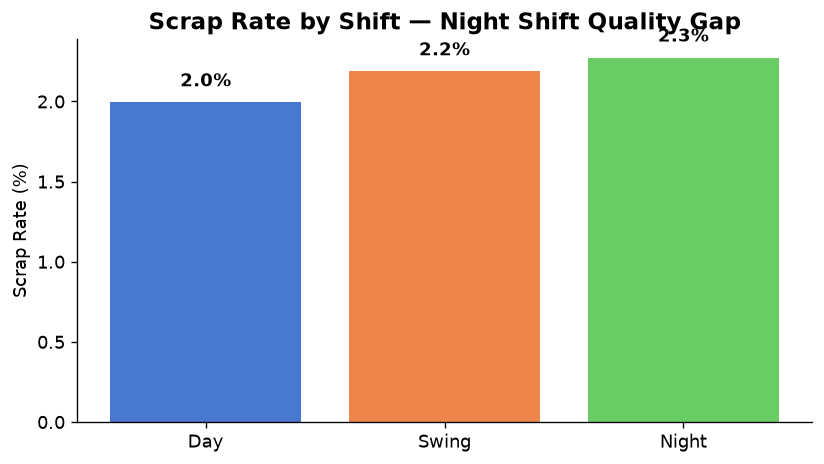

In [19]:
shift_scrap = (
    prod.groupby("shift")
    .apply(lambda g: (g["status"] == "scrapped").mean())
    .reindex([1, 2, 3])
)
 
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["Day", "Swing", "Night"], shift_scrap.values * 100,
              color=COLORS[:3])
for bar, val in zip(bars, shift_scrap.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f"{val:.1%}", ha="center", fontweight="bold")
ax.set_ylabel("Scrap Rate (%)")
ax.set_title("Scrap Rate by Shift — Night Shift Quality Gap")
savefig("09_scrap_by_shift")

### Operator Performance at Assembly (the highest variability station)

=== OPERATOR PERFORMANCE AT ASSEMBLY ===

          parts_processed  median_cycle  scrap_rate
operator                                           
OP-104               3192         6.048       0.040
OP-101               3274         6.052       0.040
OP-102               3161         6.061       0.040
OP-103               3175         6.101       0.038
OP-203               3940         6.433       0.044
OP-202               4096         6.461       0.047
OP-201               3952         6.509       0.043
OP-301               5573         6.826       0.048
OP-302               5661         6.844       0.049


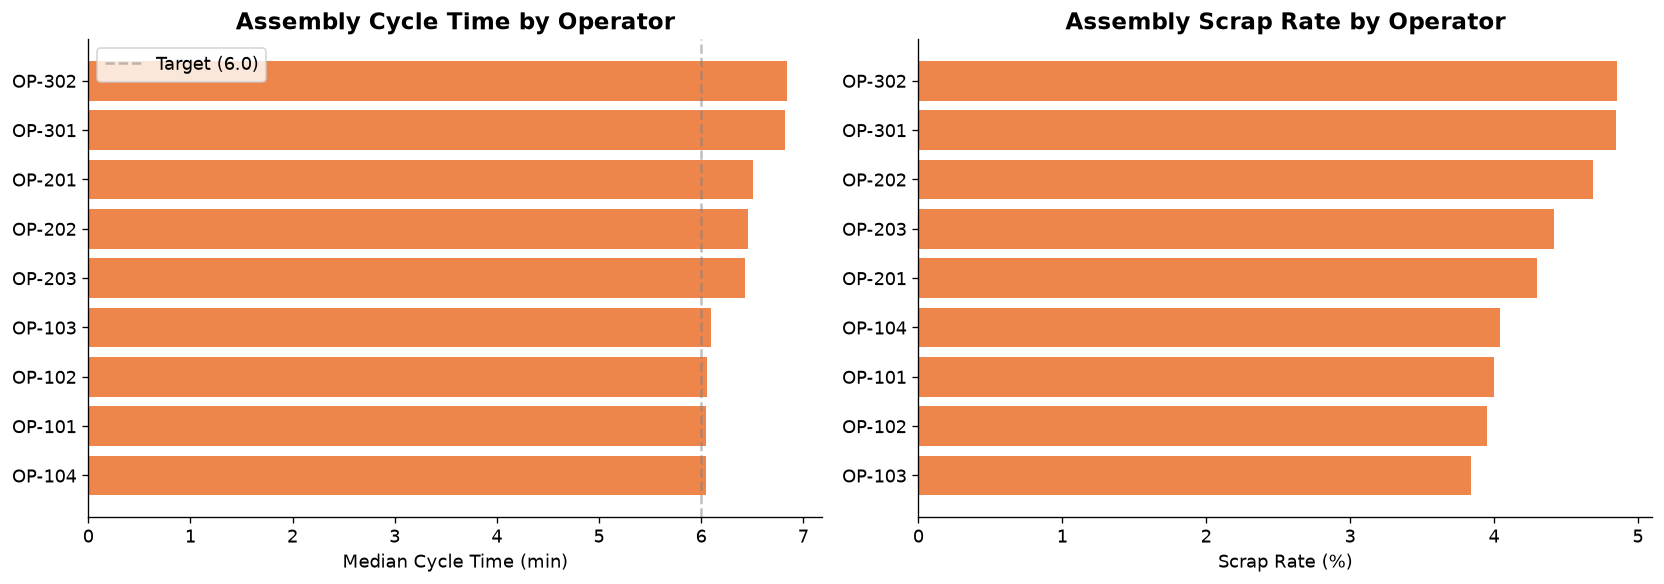

In [20]:
assembly = prod[prod["station"] == "S3_Assembly"]
op_perf = (
    assembly.groupby("operator")
    .agg(
        parts_processed=("part_id", "count"),
        median_cycle=("cycle_time_min", "median"),
        scrap_rate=("status", lambda x: (x == "scrapped").mean()),
    )
    .sort_values("median_cycle")
)

print("=== OPERATOR PERFORMANCE AT ASSEMBLY ===\n")
print(op_perf.round(3).to_string())
 
# %%
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
 
# Cycle time by operator
op_sorted = op_perf.sort_values("median_cycle")
ax1.barh(op_sorted.index, op_sorted["median_cycle"], color=COLORS[1])
ax1.set_xlabel("Median Cycle Time (min)")
ax1.set_title("Assembly Cycle Time by Operator")
ax1.axvline(x=6.0, color="gray", linestyle="--", alpha=0.5, label="Target (6.0)")
ax1.legend()
 
# Scrap rate by operator
op_sorted2 = op_perf.sort_values("scrap_rate", ascending=True)
colors_scrap = [COLORS[3] if v > 0.06 else COLORS[1] for v in op_sorted2["scrap_rate"]]
ax2.barh(op_sorted2.index, op_sorted2["scrap_rate"] * 100, color=colors_scrap)
ax2.set_xlabel("Scrap Rate (%)")
ax2.set_title("Assembly Scrap Rate by Operator")
 
savefig("10_operator_performance")

# Key Finding and Cost of Quality

## Cost of Quality Estimation

=== ESTIMATED COST OF QUALITY (Q1 2024, 90 days) ===

  Scrap — material loss    : $      48,175
  Scrap — wasted labor     : $      14,041
  Downtime — idle labor    : $       7,661
  Overtime premium         : $      54,112
  Delivery penalties (est) : $      39,000
  ────────────────────────────────────────
  TOTAL COST OF QUALITY    : $     162,990
  Annualized               : $     651,960


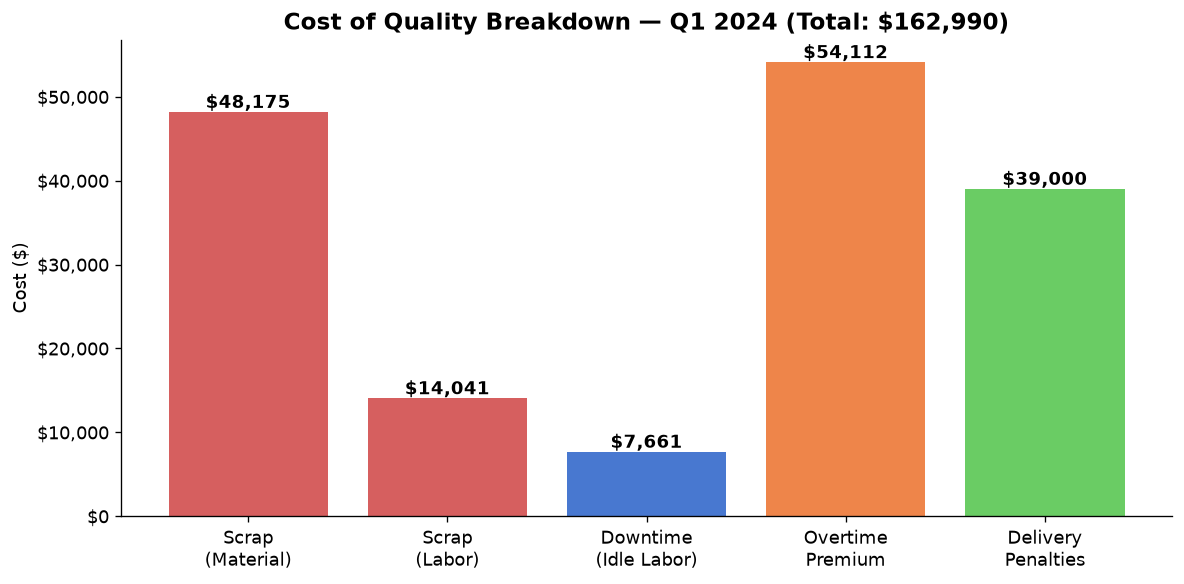

In [21]:
# Assumptions (typical for precision metal fab)
COST_PER_PART_MATERIAL = 12.50    # Raw material per unit
COST_PER_PART_LABOR_MIN = 0.75    # Loaded labor rate per minute
OVERTIME_PREMIUM_RATE = 22.50     # $/hr overtime premium above base
MISSED_DELIVERY_PENALTY = 500     # Per-incident penalty estimate
AVG_WEEKLY_COMPLAINTS = 6         # From brief: 5-7 per month
WEEKS = 13                        # 90 days

# Scrap cost
scrap_material = parts_scrapped * COST_PER_PART_MATERIAL
avg_time_before_scrap = (
    prod[prod["status"] == "scrapped"]
    .groupby("part_id")["cycle_time_min"]
    .sum()
    .mean()
)
scrap_labor = parts_scrapped * avg_time_before_scrap * COST_PER_PART_LABOR_MIN

# Downtime cost (idle operators + lost throughput)
total_down_min = down["duration_min"].sum()
downtime_labor = total_down_min * COST_PER_PART_LABOR_MIN * 3  # ~3 operators idle
 
# Excess queue/WIP cost (proxy: queue time × labor rate for waiting operators)
total_queue_min = prod["queue_wait_min"].sum()
queue_cost = total_queue_min * COST_PER_PART_LABOR_MIN * 0.3  # 30% allocation
 
# Overtime estimate from brief
overtime_cost = 185 * OVERTIME_PREMIUM_RATE * WEEKS  # 185 hrs/wk from brief
 
# Missed delivery penalties
delivery_penalties = AVG_WEEKLY_COMPLAINTS * MISSED_DELIVERY_PENALTY * WEEKS
 
total_coq = scrap_material + scrap_labor + downtime_labor + overtime_cost + delivery_penalties

print("=== ESTIMATED COST OF QUALITY (Q1 2024, 90 days) ===\n")
print(f"  Scrap — material loss    : ${scrap_material:>12,.0f}")
print(f"  Scrap — wasted labor     : ${scrap_labor:>12,.0f}")
print(f"  Downtime — idle labor    : ${downtime_labor:>12,.0f}")
print(f"  Overtime premium         : ${overtime_cost:>12,.0f}")
print(f"  Delivery penalties (est) : ${delivery_penalties:>12,.0f}")
print(f"  {'─' * 40}")
print(f"  TOTAL COST OF QUALITY    : ${total_coq:>12,.0f}")
print(f"  Annualized               : ${total_coq * 4:>12,.0f}")

# Cost of quality breakdown chart
coq_items = ["Scrap\n(Material)", "Scrap\n(Labor)", "Downtime\n(Idle Labor)",
             "Overtime\nPremium", "Delivery\nPenalties"]
coq_values = [scrap_material, scrap_labor, downtime_labor,
              overtime_cost, delivery_penalties]
 
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(coq_items, coq_values, color=[COLORS[3], COLORS[3],
              COLORS[0], COLORS[1], COLORS[2]])
for bar, val in zip(bars, coq_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f"${val:,.0f}", ha="center", fontweight="bold")
ax.set_ylabel("Cost ($)")
ax.set_title(f"Cost of Quality Breakdown — Q1 2024 "
             f"(Total: ${total_coq:,.0f})")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
savefig("11_cost_of_quality")

# Summary of Key Findings

**1. Assembly is the bottleneck.** S3 shows the longest queue waits and highest cycle time variability. Its manual nature makes it the primary constraint on throughput.

**2.  Night shift is underperforming.** Scrap rates are materially higher on the night shift, driven by fewer operators and fatigue effects at manual stations. Cycle times also increase 10–15%.

**3. CNC downtime is the biggest equipment reliability issue.** Despite having 2 machines, CNC Machining accounts for a disproportionate share of total downtime hours, primarily due to spindle failures and tool breakage.

**4. The cost of quality is substantial.** Overtime alone is the largest single cost driver, reflecting that RMW is compensating for structural capacity issues with brute-force labor hours.

**Next step:** Model 2–3 automation scenarios (cobot assembly, machine vision inspection, predictive maintenance on CNC) and compare projected OEE, throughput, and ROI to this baseline.